In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv('data/orders.csv')
weekly = orders.groupby('week').size().rename('orders').reset_index()
weekly.tail()

,week,orders
47,47,289
48,48,272
49,49,249
50,50,231
51,51,215


In [2]:
weekly['moving_avg_4w'] = weekly['orders'].rolling(window=4).mean()
weekly.tail()

,week,orders,moving_avg_4w
47,47,289,332.00
48,48,272,305.75
49,49,249,282.00
50,50,231,260.25
51,51,215,241.75


In [3]:
forecast_next_week = weekly['moving_avg_4w'].iloc[-1]
print(f'Forecast for next week: about {forecast_next_week:.0f} orders')

Forecast for next week: about 242 orders


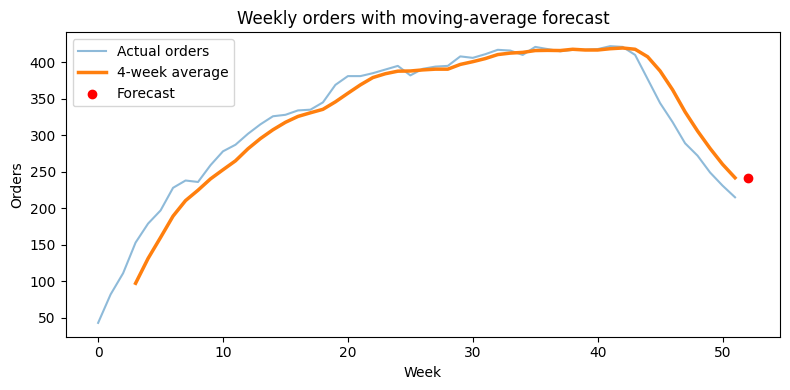

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(weekly['week'], weekly['orders'], alpha=0.5, label='Actual orders')
plt.plot(weekly['week'], weekly['moving_avg_4w'], linewidth=2.5, label='4-week average')
next_week = weekly['week'].iloc[-1] + 1
plt.scatter([next_week], [forecast_next_week], color='red', zorder=5, label='Forecast')
plt.title('Weekly orders with moving-average forecast')
plt.xlabel('Week'); plt.ylabel('Orders')
plt.legend(); plt.tight_layout(); plt.show()